# Project Akhir Data Mining — Smart Farming
## Supervised Learning dan Unsupervised Learning pada Crop Recommendation Dataset

Notebook ini dibuat untuk project akhir Data Mining bertema **Living Lab / Smart Farming**.

Topik project:

> **Penerapan Random Forest dan K-Means pada Crop Recommendation Dataset untuk Mendukung Smart Farming**

Notebook ini berisi dua pendekatan data mining:

1. **Supervised Learning**  
   Memprediksi jenis tanaman yang cocok berdasarkan kondisi tanah dan cuaca menggunakan **Random Forest**.

2. **Unsupervised Learning**  
   Mengelompokkan kondisi lahan berdasarkan kemiripan atribut tanah dan cuaca menggunakan **K-Means Clustering**.

Dataset yang digunakan: **Crop Recommendation Dataset**  
Link: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

## 1. Import Library

Library yang digunakan:

- `pandas` untuk membaca dan mengolah dataset.
- `numpy` untuk operasi numerik.
- `matplotlib` dan `seaborn` untuk visualisasi.
- `scikit-learn` untuk machine learning, evaluasi, preprocessing, dan clustering.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset

In [31]:
file_path = '/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv'

df = pd.read_csv(file_path)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Memahami Dataset

Dataset ini biasanya memiliki kolom:

- `N`: kandungan Nitrogen.
- `P`: kandungan Phosphorus/Fosfor.
- `K`: kandungan Potassium/Kalium.
- `temperature`: suhu.
- `humidity`: kelembapan udara.
- `ph`: tingkat keasaman tanah.
- `rainfall`: curah hujan.
- `label`: jenis tanaman yang cocok.

Pada project ini:

- Kolom `label` digunakan untuk **supervised learning**.
- Kolom numerik digunakan untuk **unsupervised learning**.

In [32]:
print('Ukuran dataset:', df.shape)
print('\nInfo dataset:')
df.info()

Ukuran dataset: (2200, 8)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [33]:
print('Jumlah data kosong per kolom:')
df.isnull().sum()

Jumlah data kosong per kolom:


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [34]:
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 0


In [35]:
print('Statistik deskriptif:')
df.describe()

Statistik deskriptif:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [36]:
print('Daftar label tanaman:')
print(df['label'].unique())
print('\nJumlah kelas tanaman:', df['label'].nunique())

Daftar label tanaman:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Jumlah kelas tanaman: 22


## 4. Exploratory Data Analysis / EDA

Bagian ini digunakan untuk melihat gambaran awal dataset.

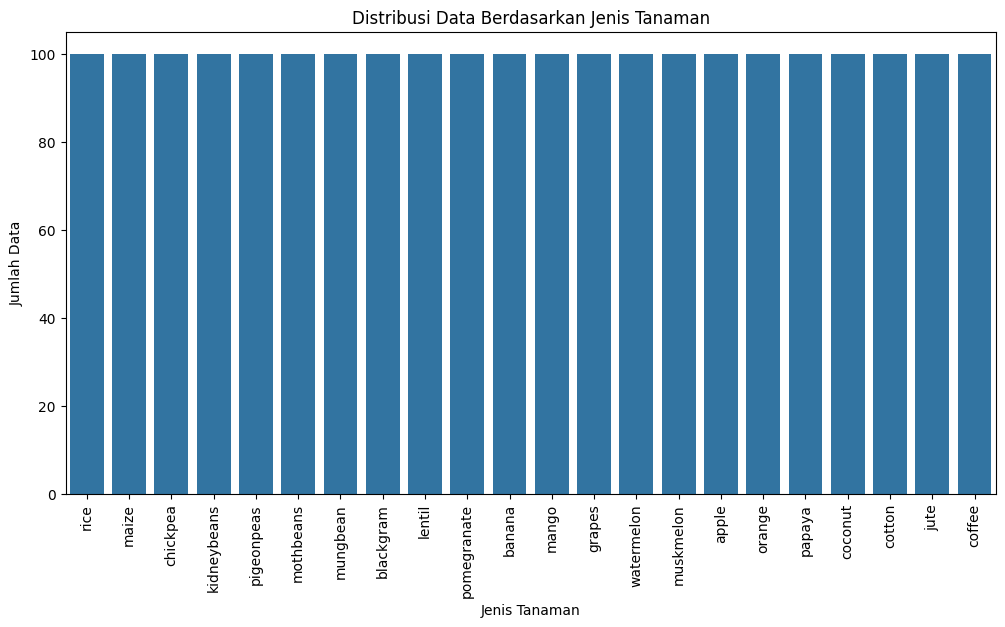

In [37]:
# Distribusi jumlah data tiap jenis tanaman
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Distribusi Data Berdasarkan Jenis Tanaman')
plt.xlabel('Jenis Tanaman')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=90)
plt.show()

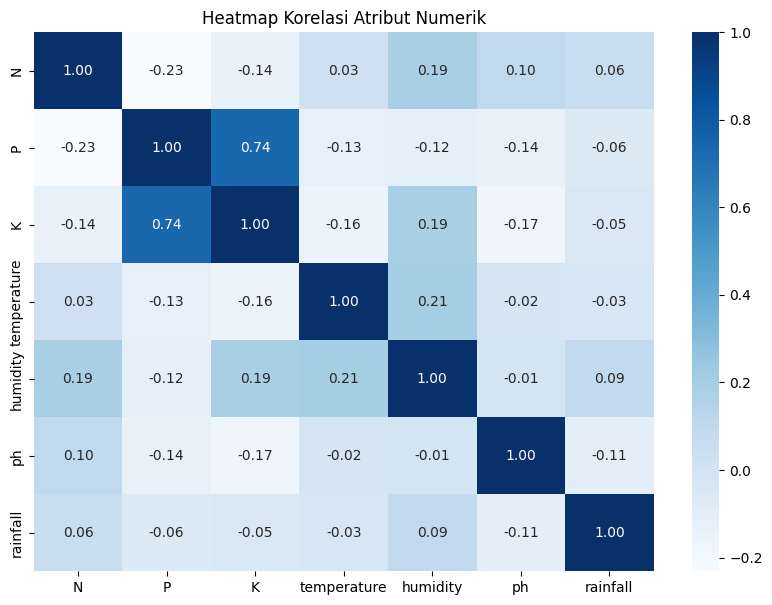

In [38]:
# Korelasi antar atribut numerik
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi Atribut Numerik')
plt.show()

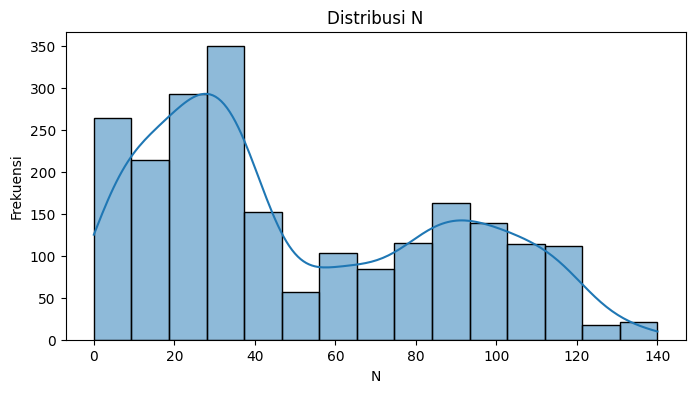

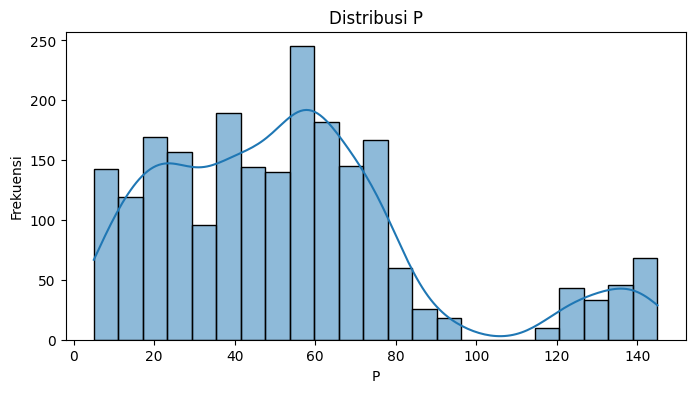

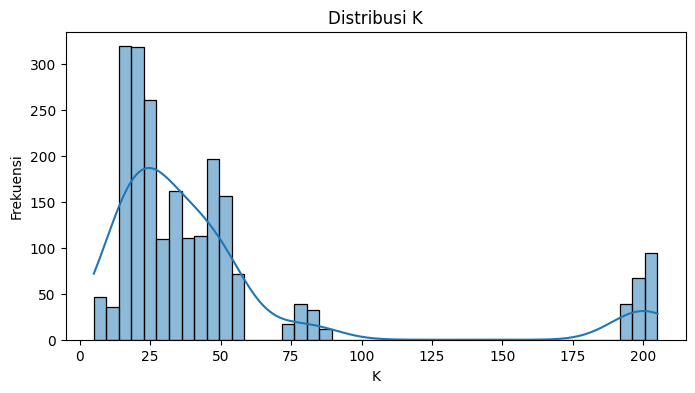

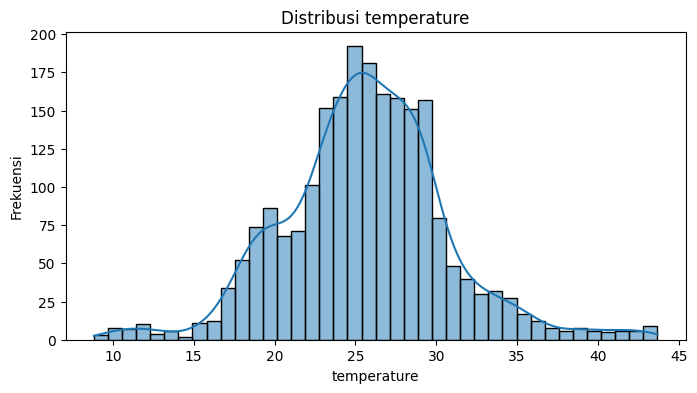

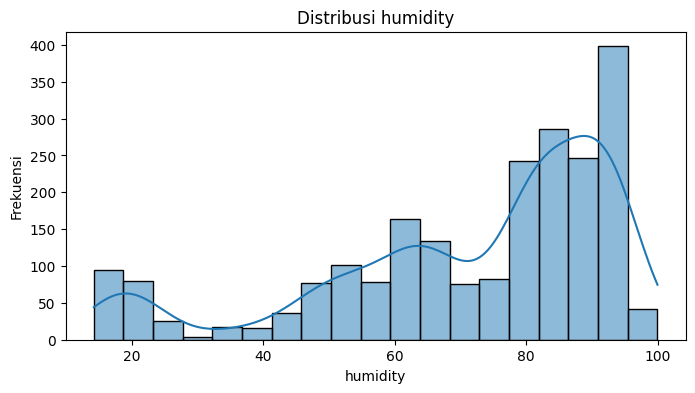

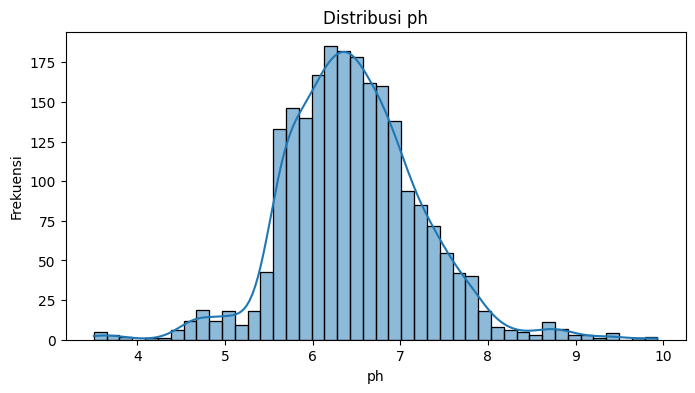

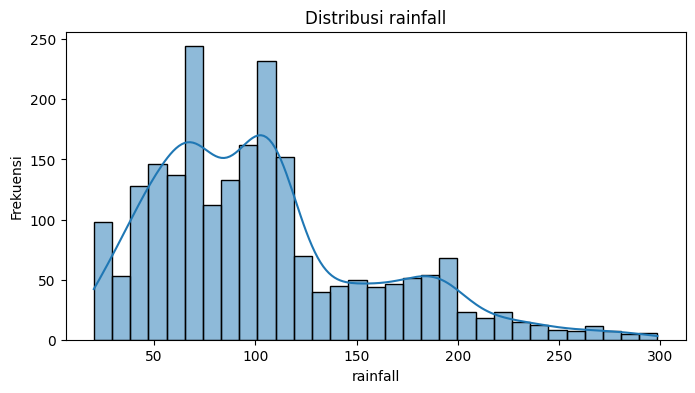

In [39]:
# Visualisasi sederhana beberapa atribut penting
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

# BAGIAN A — Supervised Learning

## Tujuan

Membuat model yang dapat **memprediksi jenis tanaman** berdasarkan kondisi tanah dan cuaca.

## Algoritma

Algoritma yang digunakan adalah **Random Forest Classifier**.

Alasan pemilihan Random Forest:

1. Cocok untuk masalah klasifikasi dengan banyak kelas tanaman.
2. Lebih stabil dibanding satu Random Forest karena menggunakan banyak pohon keputusan.
3. Dapat menangani fitur numerik seperti N, P, K, temperature, humidity, ph, dan rainfall.
4. Biasanya menghasilkan akurasi yang lebih baik karena menggabungkan hasil dari banyak pohon.
5. Tetap cukup mudah dijelaskan: model membuat banyak pohon keputusan, lalu mengambil voting terbanyak sebagai hasil prediksi.


## 5. Menyiapkan Data untuk Supervised Learning

Pada supervised learning:

- `X` = fitur/input, yaitu N, P, K, temperature, humidity, ph, rainfall.
- `y` = target/output, yaitu label jenis tanaman.

In [40]:
X = df[numeric_cols]
y = df['label']

print('Fitur X:')
print(X.head())

print('\nTarget y:')
print(y.head())

Fitur X:
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Target y:
0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object


In [41]:
# Membagi data menjadi data latih dan data uji
# 80% data latih, 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji:', X_test.shape[0])

Jumlah data latih: 1760
Jumlah data uji: 440


## 6. Training Model Random Forest


In [42]:
# Membuat dan melatih model Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    class_weight=None
)

model_rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

## 7. Evaluasi Supervised Learning

Evaluasi yang digunakan:

- **Accuracy**: persentase prediksi yang benar.
- **Precision**: ketepatan prediksi pada setiap kelas.
- **Recall**: kemampuan model menemukan data pada setiap kelas.
- **F1-score**: gabungan precision dan recall.
- **Confusion Matrix**: tabel perbandingan label asli dan hasil prediksi.

In [43]:
y_pred = model_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9954545454545455

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00     

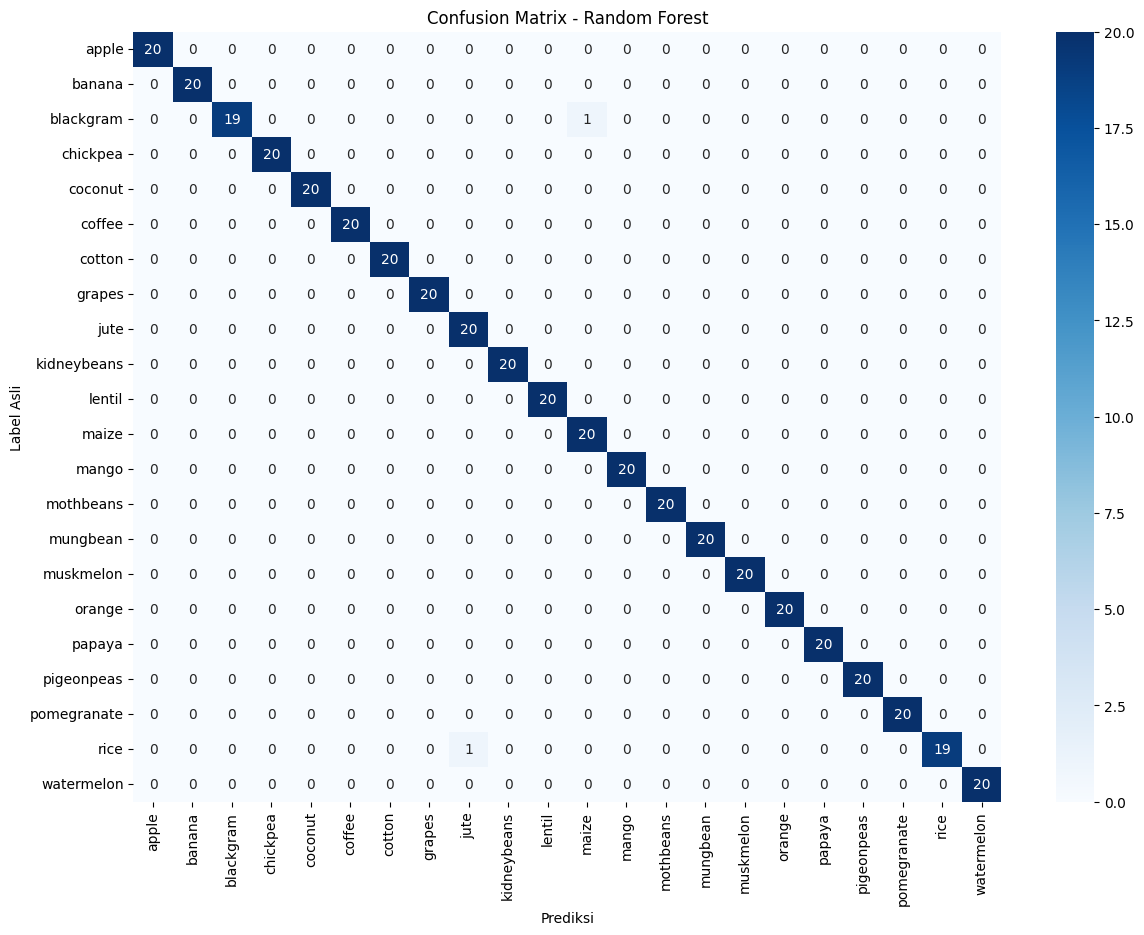

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model_rf.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_rf.classes_,
            yticklabels=model_rf.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## 8. Feature Importance Random Forest

Random Forest tidak divisualisasikan sebagai satu pohon utama karena modelnya terdiri dari banyak pohon keputusan.
Sebagai gantinya, kita tampilkan **feature importance** untuk melihat atribut mana yang paling berpengaruh terhadap prediksi tanaman.


       feature  importance
6     rainfall    0.219641
4     humidity    0.217058
2            K    0.180813
1            P    0.151342
0            N    0.103356
3  temperature    0.075485
5           ph    0.052305


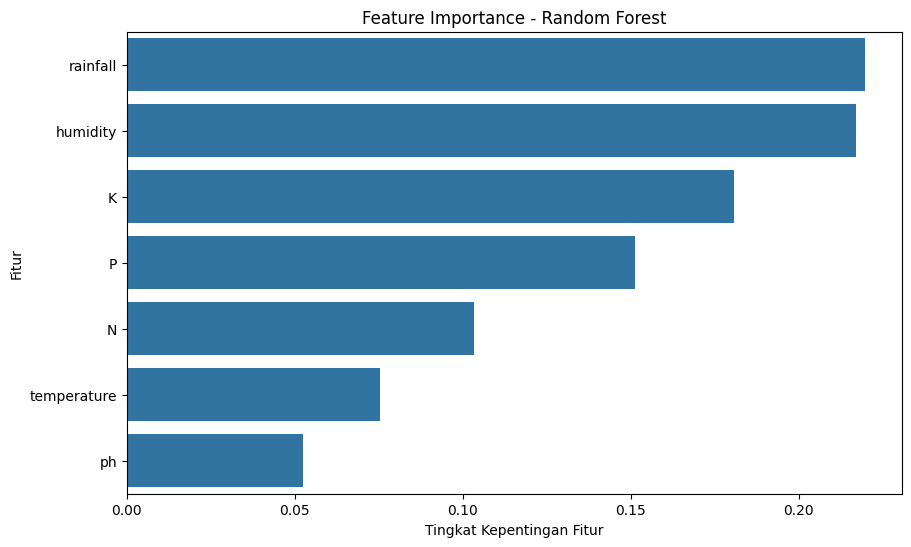

In [45]:
# Visualisasi feature importance
importances = model_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': numeric_cols,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('Fitur')
plt.show()


## 9. Contoh Prediksi Manual

Cell ini digunakan sebagai demo sederhana.

Contoh input:

- N = 90
- P = 42
- K = 43
- temperature = 20.8
- humidity = 82
- ph = 6.5
- rainfall = 202

In [46]:
contoh_data = pd.DataFrame({
    'N': [90],
    'P': [42],
    'K': [43],
    'temperature': [20.8],
    'humidity': [82],
    'ph': [6.5],
    'rainfall': [202]
})

prediksi = model_rf.predict(contoh_data)
print('Hasil prediksi tanaman:', prediksi[0])

Hasil prediksi tanaman: rice


# BAGIAN B — Unsupervised Learning

## Tujuan

Mengelompokkan data kondisi lahan berdasarkan kemiripan atribut tanah dan cuaca **tanpa menggunakan label tanaman**.

Pada bagian ini, kolom `label` tidak digunakan.

## Algoritma

Algoritma yang digunakan adalah **K-Means Clustering**.

Alasan pemilihan K-Means:

1. Mudah dipahami.
2. Cocok untuk data numerik.
3. Dapat mengelompokkan data berdasarkan kemiripan karakteristik.
4. Hasilnya dapat ditafsirkan sebagai kelompok kondisi lahan, misalnya kondisi lembap, kering, atau seimbang.

## 10. Menyiapkan Data untuk Clustering

Karena K-Means sensitif terhadap skala data, fitur numerik perlu distandardisasi menggunakan `StandardScaler`.

In [47]:
X_cluster = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled[:5]

array([[ 1.0687974 , -0.34455075, -0.1016875 , -0.93558693,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, -0.75964603,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, -0.51589814,  0.48695381,
         1.77151047,  2.92106603],
       [ 0.63529812, -0.55681099, -0.1609334 ,  0.17280704,  0.38980549,
         0.66030768,  2.53704803],
       [ 0.74367294, -0.34455075, -0.12143613, -1.08364706,  0.45479163,
         1.49786778,  2.89837267]])

## 11. Menentukan Jumlah Cluster dengan Elbow Method

Elbow Method digunakan untuk melihat jumlah cluster yang cukup baik berdasarkan nilai inertia.

Pada project ini, jumlah cluster tidak harus sama dengan jumlah jenis tanaman. Cluster lebih dimaknai sebagai **kelompok kondisi lahan**, bukan jenis tanaman.

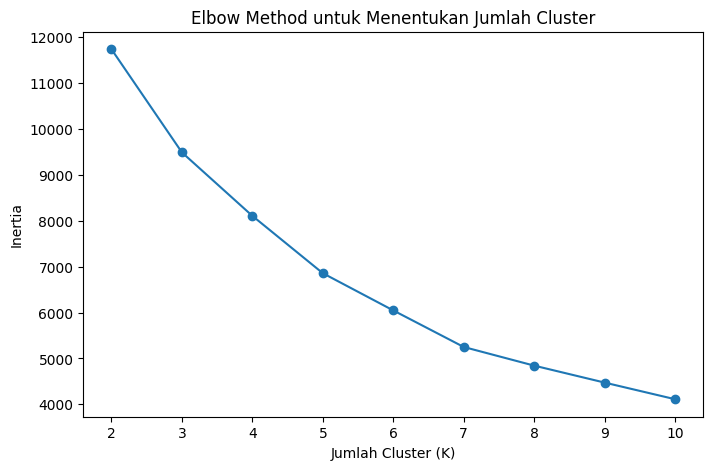

In [48]:
inertia_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

## 12. Menentukan Jumlah Cluster dengan Silhouette Score

Silhouette Score digunakan untuk menilai kualitas cluster.

Nilainya berada pada rentang -1 sampai 1.

- Mendekati 1: cluster semakin baik.
- Mendekati 0: data berada di batas antar cluster.
- Negatif: kemungkinan data masuk cluster yang kurang tepat.

K=2, Silhouette Score=0.4168
K=3, Silhouette Score=0.2519
K=4, Silhouette Score=0.2553
K=5, Silhouette Score=0.2925
K=6, Silhouette Score=0.3044
K=7, Silhouette Score=0.3333
K=8, Silhouette Score=0.3266
K=9, Silhouette Score=0.3321
K=10, Silhouette Score=0.3488


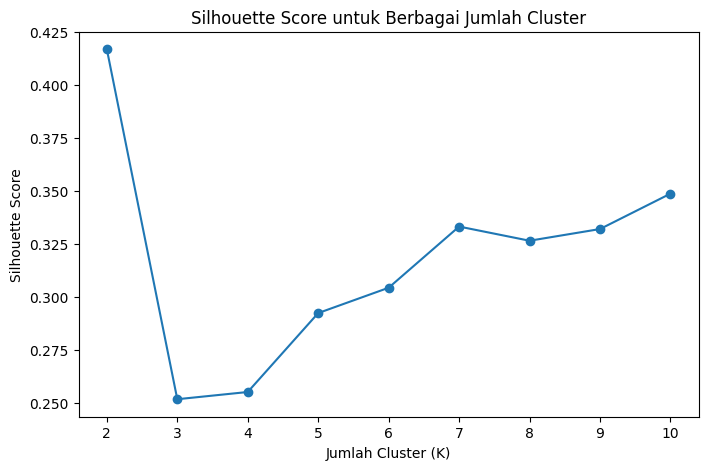

In [49]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}, Silhouette Score={score:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score untuk Berbagai Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.show()

## 13. Training K-Means

Untuk memudahkan interpretasi, notebook ini menggunakan **K = 3**.

Kalian boleh mengganti nilai `jumlah_cluster` berdasarkan hasil Elbow Method dan Silhouette Score.

In [50]:
jumlah_cluster = 3

kmeans_final = KMeans(n_clusters=jumlah_cluster, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'cluster']].head()

,N,P,K,temperature,humidity,ph,rainfall,label,cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


In [51]:
print('Jumlah data pada setiap cluster:')
print(df['cluster'].value_counts().sort_index())

Jumlah data pada setiap cluster:
cluster
0     784
1    1216
2     200
Name: count, dtype: int64


## 14. Visualisasi Cluster dengan PCA

Karena data memiliki 7 fitur numerik, kita gunakan **PCA** untuk mereduksi data menjadi 2 dimensi agar bisa divisualisasikan.

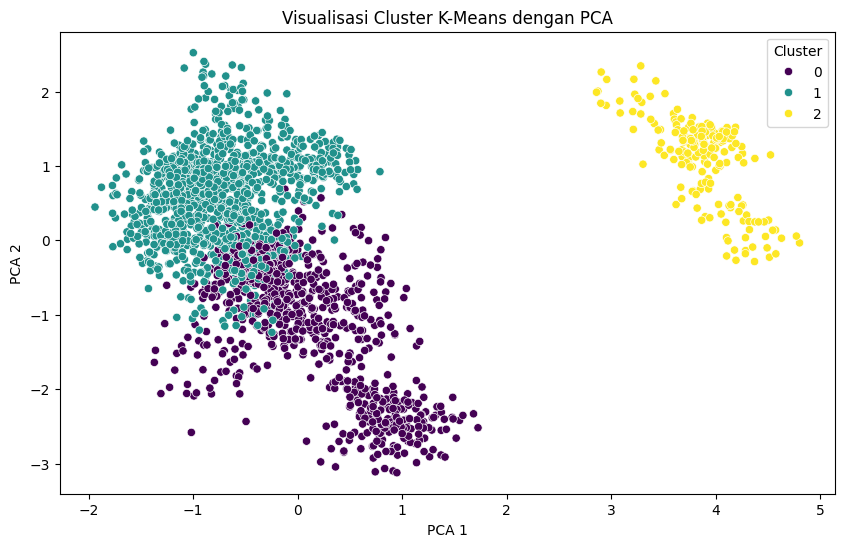

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='cluster', palette='viridis')
plt.title('Visualisasi Cluster K-Means dengan PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

## 15. Interpretasi Cluster

Bagian ini sangat penting untuk laporan dan presentasi.

Kita melihat nilai rata-rata setiap atribut pada masing-masing cluster, lalu memberi makna pada cluster tersebut.

In [53]:
cluster_summary = df.groupby('cluster')[numeric_cols].mean().round(2)
cluster_summary

,N,P,K,temperature,humidity,ph,rainfall
cluster,,,,,,,
0,25.92,57.96,28.81,25.95,49.43,6.52,80.79
1,71.13,37.24,35.64,25.79,83.13,6.52,120.11
2,21.99,133.38,200.00,23.24,87.10,5.98,91.13


In [54]:
# Melihat jenis tanaman apa saja yang paling sering muncul di setiap cluster
cluster_label_crosstab = pd.crosstab(df['cluster'], df['label'])
cluster_label_crosstab

label,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,100,100,0,0,0,0,0,100,...,100,100,71,0,0,0,96,0,0,0
1,0,100,0,0,100,100,100,0,100,0,...,0,0,29,100,100,100,4,100,100,100
2,100,0,0,0,0,0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
# Top 5 tanaman paling dominan di setiap cluster
for cluster_id in sorted(df['cluster'].unique()):
    print(f'\nCluster {cluster_id}')
    print(df[df['cluster'] == cluster_id]['label'].value_counts().head(5))


Cluster 0
label
chickpea       100
mango          100
kidneybeans    100
mothbeans      100
blackgram      100
Name: count, dtype: int64

Cluster 1
label
rice           100
banana         100
pomegranate    100
orange         100
muskmelon      100
Name: count, dtype: int64

Cluster 2
label
grapes    100
apple     100
Name: count, dtype: int64


## 16. Evaluasi Akhir Unsupervised Learning

Evaluasi utama yang digunakan adalah Silhouette Score.

In [56]:
final_silhouette = silhouette_score(X_scaled, df['cluster'])
print('Final Silhouette Score:', final_silhouette)

Final Silhouette Score: 0.2518637956538092


## 17. Contoh Narasi Interpretasi Cluster

Gunakan rata-rata atribut pada tabel `cluster_summary` untuk membuat interpretasi.

Contoh format interpretasi:

- **Cluster 0** memiliki rata-rata kelembapan dan curah hujan yang tinggi, sehingga dapat diinterpretasikan sebagai kelompok kondisi lahan yang lembap/basah.
- **Cluster 1** memiliki rata-rata suhu lebih tinggi dan curah hujan lebih rendah, sehingga dapat diinterpretasikan sebagai kelompok kondisi lahan yang lebih kering/panas.
- **Cluster 2** memiliki nilai atribut yang lebih seimbang, sehingga dapat diinterpretasikan sebagai kelompok kondisi lahan sedang/stabil.

Catatan: Sesuaikan narasi ini dengan hasil tabel `cluster_summary` yang muncul pada notebook kalian.

# 18. Kesimpulan Notebook

Berdasarkan project ini:

1. **Supervised learning** dengan Random Forest digunakan untuk memprediksi jenis tanaman berdasarkan kondisi tanah dan cuaca.
2. **Unsupervised learning** dengan K-Means digunakan untuk mengelompokkan kondisi lahan berdasarkan kemiripan atribut numerik.
3. Hasil supervised dievaluasi menggunakan accuracy, classification report, dan confusion matrix.
4. Hasil unsupervised dievaluasi menggunakan silhouette score dan interpretasi karakteristik cluster.
5. Dalam konteks Smart Farming, project ini dapat membantu proses analisis kondisi lahan dan rekomendasi tanaman berbasis data.

# 19. Catatan untuk Laporan

Masukkan hasil berikut ke laporan:

## Results

- Screenshot `df.head()`.
- Statistik dataset.
- Grafik distribusi label tanaman.
- Accuracy Random Forest.
- Classification report.
- Confusion matrix Random Forest.
- Grafik Elbow Method.
- Grafik Silhouette Score.
- Visualisasi cluster PCA.
- Tabel rata-rata atribut tiap cluster.

## Discussion

Bahas:

- Apakah model supervised memiliki performa baik?
- Tanaman mana yang sering benar/salah diprediksi?
- Cluster yang terbentuk memiliki karakteristik apa?
- Apa manfaat hasil ini untuk Smart Farming?
- Keterbatasan project, misalnya data berasal dari dataset publik dan belum diuji langsung pada lahan Living Lab.